# SIS421 - Inteligencia Artificial II
## Pipeline Multimodal de Alta Precisión para la Detección de Trampas
Este cuadernillo gestiona la descarga, el entrenamiento con RetinaNet (Torchvision), la ingeniería de datos y el entrenamiento robusto de un clasificador denso incorporando Early Stopping, Learning Rate Schedulers y Checkpoints.

In [1]:
import torch
import os
import sys
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"

print(f'Entorno Python: {sys.executable}')
print(f'Versión de PyTorch: {torch.__version__}')
cuda_status = torch.cuda.is_available()
print(f'CUDA (GPU) disponible: {"Sí" if cuda_status else "No"}')
if cuda_status:
    print(f'Tarjeta gráfica activa: {torch.cuda.get_device_name(0)}')

os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)

Entorno Python: d:\quinto_semestre\anaconda\envs\env_sis421\python.exe
Versión de PyTorch: 2.5.1
CUDA (GPU) disponible: Sí
Tarjeta gráfica activa: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [2]:
import os
import shutil
import glob

ruta_celulares = "data/cellphone"
ruta_papeles = "data/paper"
ruta_final = "data/roboflow_data"

fases = ['train', 'valid', 'test']

print("combinando datasets locales con planchado de clases...")

for fase in fases:
    os.makedirs(os.path.join(ruta_final, fase, 'images'), exist_ok=True)
    os.makedirs(os.path.join(ruta_final, fase, 'labels'), exist_ok=True)
    
    img_cel = glob.glob(os.path.join(ruta_celulares, fase, 'images', '*'))
    for p in img_cel:
        nombre = os.path.basename(p)
        name_only, _ = os.path.splitext(nombre)
        txt_p = os.path.join(ruta_celulares, fase, 'labels', name_only + '.txt')
        
        shutil.copy(p, os.path.join(ruta_final, fase, 'images', nombre))
        
        if os.path.exists(txt_p):
            with open(txt_p, 'r') as f_in:
                lineas = f_in.readlines()
            
            with open(os.path.join(ruta_final, fase, 'labels', name_only + '.txt'), 'w') as f_out:
                for line in lineas:
                    partes = line.strip().split()
                    if len(partes) > 0:
                        partes[0] = '0'
                        f_out.write(" ".join(partes) + "\n")
            
    img_pap = glob.glob(os.path.join(ruta_papeles, fase, 'images', '*'))
    for p in img_pap:
        nombre = os.path.basename(p)
        name_only, _ = os.path.splitext(nombre)
        txt_p = os.path.join(ruta_papeles, fase, 'labels', name_only + '.txt')
        
        nuevo_img = "paper_" + nombre
        nuevo_txt = "paper_" + name_only + ".txt"
        
        shutil.copy(p, os.path.join(ruta_final, fase, 'images', nuevo_img))
        
        if os.path.exists(txt_p):
            with open(txt_p, 'r') as f_in:
                lineas = f_in.readlines()
            
            with open(os.path.join(ruta_final, fase, 'labels', nuevo_txt), 'w') as f_out:
                for line in lineas:
                    partes = line.strip().split()
                    if len(partes) > 0:
                        partes[0] = '1'
                        f_out.write(" ".join(partes) + "\n")

contenido_yaml = (
    "train: data/roboflow_data/train/images\n"
    "val: data/roboflow_data/valid/images\n"
    "test: data/roboflow_data/test/images\n\n"
    "nc: 2\n"
    "names:\n"
    "  0: celular\n"
    "  1: papel\n"
)

with open(os.path.join(ruta_final, 'data.yaml'), 'w') as f:
    f.write(contenido_yaml)

print("fusion completada con exito. datos unificados en data/roboflow_data.")

combinando datasets locales con planchado de clases...
fusion completada con exito. datos unificados en data/roboflow_data.


In [3]:
import os
import cv2
import glob
import yaml
import torchvision
import torch
from PIL import Image

with open('data/roboflow_data/data.yaml', 'r') as f:
    config_dataset = yaml.safe_load(f)

print("mapeo listo -> id celular: 0 | id papel: 1")

class RetinaDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir):
        rutas_brutas = glob.glob(f"{root_dir}/images/*.jpg") + glob.glob(f"{root_dir}/images/*.jpeg")
        self.image_paths = []
        
        for r in rutas_brutas:
            nombre_base, _ = os.path.splitext(r)
            label_path = nombre_base.replace('images', 'labels') + '.txt'
            if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
                self.image_paths.append(r)
                
        print(f"parseo completado para {root_dir}: se conservaron {len(self.image_paths)} imagenes validas.")

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert("RGB")
        img_w, img_h = img.size
        
        nombre_base, _ = os.path.splitext(img_path)
        label_path = nombre_base.replace('images', 'labels') + '.txt'

        boxes = []
        labels = []
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) < 5: 
                        continue
                        
                    c = int(float(parts[0]))
                    
                    if len(parts) == 5:
                        x, y, w, h = map(float, parts[1:])
                        xmin = (x - w/2) * img_w
                        ymin = (y - h/2) * img_h
                        xmax = (x + w/2) * img_w
                        ymax = (y + h/2) * img_h
                    else:
                        coords = list(map(float, parts[1:]))
                        xs = coords[0::2]
                        ys = coords[1::2]
                        xmin = min(xs) * img_w
                        ymin = min(ys) * img_h
                        xmax = max(xs) * img_w
                        ymax = max(ys) * img_h
                    
                    xmin, ymin = max(0, xmin), max(0, ymin)
                    xmax, ymax = min(img_w, xmax), min(img_h, ymax)
                    
                    if xmax > xmin and ymax > ymin:
                        boxes.append([xmin, ymin, xmax, ymax])
                        labels.append(c)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        target = {"boxes": boxes, "labels": labels}

        img = torchvision.transforms.functional.to_tensor(img)
        return img, target

    def __len__(self):
        return len(self.image_paths)

def collate_fn(batch):
    return tuple(zip(*batch))

print("clase de lectura preparada")

mapeo listo -> id celular: 0 | id papel: 1
clase de lectura preparada


In [4]:
from torchvision.models.detection.retinanet import retinanet_resnet50_fpn_v2, RetinaNetClassificationHead

device_target = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'iniciando entrenamiento de retinanet en: {device_target}...')

train_dataset_retina = RetinaDataset('data/roboflow_data/train')
train_loader_retina = torch.utils.data.DataLoader(
    train_dataset_retina, batch_size=4, shuffle=True, num_workers=0, collate_fn=collate_fn
)

num_classes = 2 

model_retina = retinanet_resnet50_fpn_v2(weights='DEFAULT')
in_features = model_retina.head.classification_head.conv[0][0].in_channels
num_anchors = model_retina.head.classification_head.num_anchors

model_retina.head.classification_head = RetinaNetClassificationHead(
    in_channels=in_features, num_anchors=num_anchors, num_classes=num_classes
)
model_retina.to(device_target)

optimizer_retina = torch.optim.AdamW(model_retina.parameters(), lr=1e-4)

epochs_retina = 8
model_retina.train()

for epoch in range(epochs_retina):
    epoch_loss = 0.0
    for images, targets in train_loader_retina:
        images = list(image.to(device_target) for image in images)
        targets = [{k: v.to(device_target) for k, v in t.items()} for t in targets]
        
        loss_dict = model_retina(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        optimizer_retina.zero_grad()
        losses.backward()
        optimizer_retina.step()
        
        epoch_loss += losses.item()
        
    print(f'epoca [{epoch+1:02d}/{epochs_retina}] -> loss: {epoch_loss/len(train_loader_retina):.4f}')

torch.save(model_retina.state_dict(), 'models/retinanet.pth')
print('modelo retinanet guardado con exito.')

iniciando entrenamiento de retinanet en: cuda...
parseo completado para data/roboflow_data/train: se conservaron 2638 imagenes validas.
epoca [01/8] -> loss: 0.3714
epoca [02/8] -> loss: 0.1767
epoca [03/8] -> loss: 0.1477
epoca [04/8] -> loss: 0.1219
epoca [05/8] -> loss: 0.0951
epoca [06/8] -> loss: 0.1094
epoca [07/8] -> loss: 0.0836
epoca [08/8] -> loss: 0.0758
modelo retinanet guardado con exito.


In [5]:
import csv
import cv2
import glob
import os
import torch
import torchvision.transforms.functional as F
from src.pose import get_pose_features

phone_id = 0 
paper_id = 1

model_retina.to(device_target)
model_retina.eval()

lista_carpetas = glob.glob("data/OEP_database/subject*")
lista_carpetas.sort()

print(f"leyendo {len(lista_carpetas)} carpetas de sujetos...")

archivo_csv = open('data/dataset.csv', 'w', newline='')
escritor = csv.writer(archivo_csv)
escritor.writerow(['prob_phone', 'prob_paper', 'angle', 'dist', 'offset_x', 'label'])

for carpeta in lista_carpetas:
    print("procesando:", os.path.basename(carpeta))
    
    videos = glob.glob(carpeta + "/*.avi")
    archivo_gt = carpeta + "/gt.txt"
    
    if len(videos) == 0 or not os.path.exists(archivo_gt):
        continue
        
    intervalos_trampa = []
    f_gt = open(archivo_gt, "r")
    for linea in f_gt.readlines():
        partes = linea.strip().split()
        if len(partes) == 3:
            str_inicio = partes[0]
            str_fin = partes[1]
            tipo_codigo = int(partes[2])
            
            seg_inicio = int(str_inicio[:2]) * 60 + int(str_inicio[2:])
            seg_fin = int(str_fin[:2]) * 60 + int(str_fin[2:])
            
            if tipo_codigo in [1, 2]:
                intervalos_trampa.append((seg_inicio, seg_fin))
    f_gt.close()
    
    for ruta_video in videos:
        nombre_archivo = os.path.basename(ruta_video).lower()

        if "2.avi" in nombre_archivo:
            continue
            
        print(f" video frontal: {os.path.basename(ruta_video)}")
        cap = cv2.VideoCapture(ruta_video)
        
        fps = cap.get(cv2.CAP_PROP_FPS)
        if fps == 0: fps = 30.0
        
        contador_cuadro = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break

            if contador_cuadro % 10 == 0:
                frame = cv2.resize(frame, (640, 480))
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                
                tensor_img = F.to_tensor(frame_rgb).to(device_target)
                with torch.no_grad():
                    resultado = model_retina([tensor_img])[0]
                
                scores = resultado['scores'].cpu().numpy()
                labels = resultado['labels'].cpu().numpy()
                
                p_phone = 0.0
                p_paper = 0.0
                
                for i in range(len(scores)):
                    score_actual = scores[i]
                    if score_actual > 0.3:
                        clase_id = labels[i] - 1
                        if clase_id == phone_id and score_actual > p_phone: 
                            p_phone = score_actual
                        if clase_id == paper_id and score_actual > p_paper: 
                            p_paper = score_actual
                
                pose_data = get_pose_features(frame_rgb)
                
                segundo_actual = contador_cuadro / fps
                
                clase_real = 0
                for inicio, fin in intervalos_trampa:
                    if segundo_actual >= inicio and segundo_actual <= fin:
                        clase_real = 1
                        break
                    
                escritor.writerow([p_phone, p_paper, pose_data[0], pose_data[1], pose_data[2], clase_real])
                
            contador_cuadro += 1
            
        cap.release()
        
    print(f"terminado {os.path.basename(carpeta)}")

archivo_csv.close()
print("terminado. dataset.csv guardado correctamente.")

leyendo 24 carpetas de sujetos...
procesando: subject1
 video frontal: Yousef1.avi
terminado subject1
procesando: subject10
 video frontal: huangpi21.avi
terminado subject10
procesando: subject11
 video frontal: alhashe31.avi
terminado subject11
procesando: subject12
 video frontal: makiluke1.avi
terminado subject12
procesando: subject13
 video frontal: guolingh1.avi
terminado subject13
procesando: subject14
 video frontal: chuangy61.avi
terminado subject14
procesando: subject15
 video frontal: bajajpak1.avi
terminado subject15
procesando: subject16
 video frontal: dhingra51.avi
terminado subject16
procesando: subject17
 video frontal: zhoulian1.avi
terminado subject17
procesando: subject18
 video frontal: yuqianyi1.avi
terminado subject18
procesando: subject19
 video frontal: wangyus11.avi
terminado subject19
procesando: subject2
 video frontal: Jourabloo1.avi
terminado subject2
procesando: subject20
 video frontal: Cool1.avi
terminado subject20
procesando: subject21
 video frontal: M

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.network import CheatingLSTM

class DatasetMateriaSecuencial(Dataset):
    def __init__(self, ruta_csv, tamano_ventana=15):
        df = pd.read_csv(ruta_csv)
        self.datos = df.iloc[:, :-1].values  
        self.etiquetas = df.iloc[:, -1].values 
        self.w_size = tamano_ventana
        
    def __len__(self):
        return len(self.datos) - self.w_size + 1
        
    def __getitem__(self, idx):
        
        X_seq = self.datos[idx : idx + self.w_size]
        y_label = self.etiquetas[idx + self.w_size - 1]
        
        return torch.tensor(X_seq, dtype=torch.float32), torch.tensor([y_label], dtype=torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset_materia = DatasetMateriaSecuencial('data/dataset.csv', tamano_ventana=15)

train_size = int(0.8 * len(dataset_materia))
val_size = len(dataset_materia) - train_size
train_data, val_data = random_split(dataset_materia, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False)

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

def fit(model, train_loader, val_loader, epochs=15, lr_rate=0.001, class_weight=3.5, early_patience=8):
    criterion = nn.BCELoss(reduction='none')
    optimizador = optim.Adam(model.parameters(), lr=lr_rate)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizador, mode='min', factor=0.5, patience=5)
    
    global historial_train_loss, historial_train_acc, historial_val_loss, historial_val_acc
    historial_train_loss, historial_train_acc = [], []
    historial_val_loss, historial_val_acc = [], []
    
    mejor_loss_val = float('inf')
    contador_paciencia = 0
    
    print("empezando el entrenamiento modular de la red lstm...")
    
    for epoch in range(epochs):
        model.train()
        suma_loss_train = 0.0
        correctas_train = 0
        total_muestras_train = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizador.zero_grad()
            outputs = model(inputs)
            
            loss_base = criterion(outputs, labels)
            pesos = torch.where(labels == 1.0, class_weight, 1.0)
            
            loss_ponderado = (loss_base * pesos).mean()
            
            loss_ponderado.backward()
            optimizador.step()
            
            suma_loss_train += loss_ponderado.item() * inputs.size(0)
            
            predicciones_train = (outputs >= 0.5).float()
            correctas_train += (predicciones_train == labels).sum().item()
            total_muestras_train += labels.size(0)
            
        model.eval()
        suma_loss_val = 0.0
        correctas_val = 0
        total_muestras_val = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                
                loss_base = criterion(outputs, labels)
                pesos = torch.where(labels == 1.0, class_weight, 1.0)
                loss_ponderado = (loss_base * pesos).mean()
                
                suma_loss_val += loss_ponderado.item() * inputs.size(0)
                
                predicciones_val = (outputs >= 0.5).float()
                correctas_val += (predicciones_val == labels).sum().item()
                total_muestras_val += labels.size(0)
                    
        error_train = suma_loss_train / len(train_loader.dataset)
        acc_train = (correctas_train / total_muestras_train) * 100.0
        
        error_val = suma_loss_val / len(val_loader.dataset)
        acc_val = (correctas_val / total_muestras_val) * 100.0
        
        historial_train_loss.append(error_train)
        historial_train_acc.append(acc_train)
        historial_val_loss.append(error_val)
        historial_val_acc.append(acc_val)
        
        scheduler.step(error_val)
        
        print(f"epoca {epoch+1:02d}/{epochs} -> train loss: {error_train:.4f}, train acc: {acc_train:.2f}% | val loss: {error_val:.4f}, val acc: {acc_val:.2f}%")

        if error_val < mejor_loss_val:
            mejor_loss_val = error_val
            contador_paciencia = 0 
            torch.save(model.state_dict(), "models/best_lstm.pth")
        else:
            contador_paciencia += 1
            print(f" sin mejora. paciencia de parada: {contador_paciencia} de {early_patience}")
            
        if contador_paciencia >= early_patience:
            print(f"\nearly stopping activado en la epoca {epoch+1}.")
            break

    print("\nentrenamiento terminado.")

In [3]:
epocas = 35
lr = 0.001
penalizacion = 3.5
paciencia = 6

modelo_sistema = CheatingLSTM().to(device)

fit(
    model=modelo_sistema, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    epochs=epocas, 
    lr_rate=lr, 
    class_weight=penalizacion, 
    early_patience=paciencia
)

empezando el entrenamiento modular de la red lstm...
epoca 01/35 -> train loss: 0.9963, train acc: 72.93% | val loss: 0.9654, val acc: 67.57%
epoca 02/35 -> train loss: 0.9654, train acc: 64.48% | val loss: 0.9566, val acc: 58.85%
epoca 03/35 -> train loss: 0.9592, train acc: 67.32% | val loss: 0.9507, val acc: 64.72%
epoca 04/35 -> train loss: 0.9531, train acc: 67.59% | val loss: 0.9437, val acc: 68.12%
epoca 05/35 -> train loss: 0.9488, train acc: 67.91% | val loss: 0.9510, val acc: 60.95%
 sin mejora. paciencia de parada: 1 de 6
epoca 06/35 -> train loss: 0.9476, train acc: 68.32% | val loss: 0.9384, val acc: 68.91%
epoca 07/35 -> train loss: 0.9427, train acc: 68.68% | val loss: 0.9388, val acc: 70.68%
 sin mejora. paciencia de parada: 1 de 6
epoca 08/35 -> train loss: 0.9391, train acc: 68.71% | val loss: 0.9307, val acc: 67.31%
epoca 09/35 -> train loss: 0.9383, train acc: 69.08% | val loss: 0.9317, val acc: 70.55%
 sin mejora. paciencia de parada: 1 de 6
epoca 10/35 -> train lo

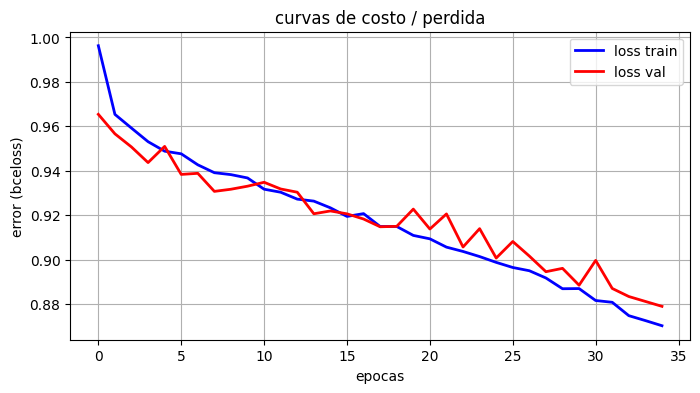

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(historial_train_loss, label='loss train', color='blue', linewidth=2)
plt.plot(historial_val_loss, label='loss val', color='red', linewidth=2)
plt.title('curvas de costo / perdida')
plt.xlabel('epocas')
plt.ylabel('error (bceloss)')
plt.legend()
plt.grid(True)
plt.show()

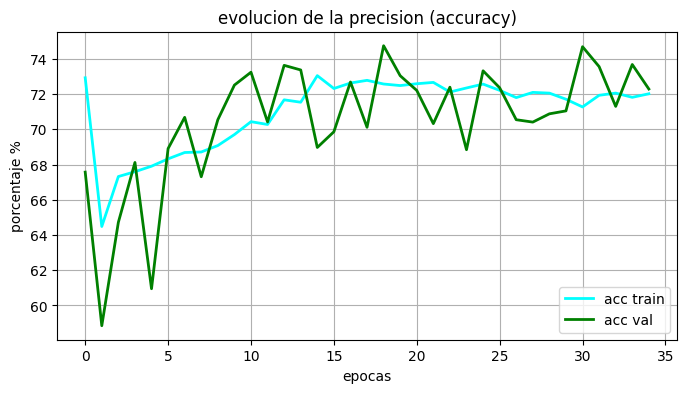

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(historial_train_acc, label='acc train', color='cyan', linewidth=2)
plt.plot(historial_val_acc, label='acc val', color='green', linewidth=2)
plt.title('evolucion de la precision (accuracy)')
plt.xlabel('epocas')
plt.ylabel('porcentaje %')
plt.legend()
plt.grid(True)
plt.show()